# Automatic Classification of Javanese Gamelan Forms from Kepatihan Cipher Notation

This notebook reproduces the complete experimental pipeline for classifying Javanese gamelan compositions by their **bentuk** (cyclic architectural form) directly from symbolic Kepatihan notation PDFs.

**Forms classified (7 classes):** Ayak-Ayak, Bubaran, Ketawang, Ladrang, Lancaran, Sampak, Srepegan

All core logic lives in the `src/` package — this notebook orchestrates the pipeline and visualises results.

## Table of Contents

1. [Setup & Dependencies](#1-setup)
2. [Dataset Overview](#2-dataset)
3. [PDF Parsing & Feature Extraction](#3-parsing)
4. [Exploratory Data Analysis](#4-eda)
5. [Evaluation Protocol](#5-protocol)
6. [Model 1 — Decision Tree](#6-dt)
7. [Model 2 — Random Forest](#7-rf)
8. [Model 3 — Support Vector Machine](#8-svm)
9. [Model 4 — k-Nearest Neighbors](#9-knn)
10. [Model 5 — MLP (Neural Network)](#10-mlp)
11. [Model 6 — 1D CNN](#11-cnn)
12. [Model Comparison](#12-comparison)
13. [Conclusions](#13-conclusions)

---
## 1. Setup & Dependencies <a id='1-setup'></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight

import torch

# ── Project modules ──────────────────────────────────────────────────────────
from src.parser import Note, extract_raw_text, parse_notation, pad_or_truncate, N_DIMS
from src.features import extract_features, FEATURE_NAMES, N_FEATURES
from src.data import (
    load_corpus_features, load_corpus_sequences,
    stratified_split, to_arrays, to_tensors,
)
from src.statistical_analysis import (
    load_corpus as load_corpus_parsed, aggregate, all_notes, genre_colors,
)
from src.gamelan_mlp import GamelanMLP, train as train_mlp
from src.gamelan_cnn import GamelanCNN, train_model as train_cnn
from src.plots import plot_embedding_pca

torch.manual_seed(42)
np.random.seed(42)

%matplotlib inline
plt.rcParams.update({"figure.facecolor": "#FAFAF8", "axes.facecolor": "#F8F5F0", "font.size": 10})

PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653", "#A8DADC", "#9B2335"]
DATASET_ROOT = Path("dataset")

print(f"Dataset path: {DATASET_ROOT.resolve()}")
print(f"Exists: {DATASET_ROOT.exists()}")

Dataset path: /home/frederic/Documents/UPF/semester2/Symbolic/classifying-javanese-gamelan-forms/dataset
Exists: True


---
## 2. Dataset Overview <a id='2-dataset'></a>

The dataset contains **35 traditional Javanese gamelan compositions** transcribed in Kepatihan cipher notation (Kurniawati et al., *Data in Brief*, 2024). Each composition belongs to one of **7 bentuk** (form categories), with 5 pieces per form.

Each piece folder contains the main melody PDF plus instrument-specific PDFs (Balungan, Bonang, Peking, Structural). For classification, we use only the **main melody PDF** as the input.

In [2]:
dataset_summary = []
for genre_dir in sorted(DATASET_ROOT.iterdir()):
    if not genre_dir.is_dir():
        continue
    for song_dir in sorted(genre_dir.iterdir()):
        if not song_dir.is_dir():
            continue
        main_pdf = song_dir / f"{song_dir.name}.pdf"
        dataset_summary.append({
            "Form (Bentuk)": genre_dir.name,
            "Song": song_dir.name,
            "Main PDF exists": main_pdf.exists(),
            "Total PDFs": len(list(song_dir.glob("*.pdf"))),
        })

df_dataset = pd.DataFrame(dataset_summary)
print(f"Total pieces: {len(df_dataset)}")
print(f"Forms: {df_dataset['Form (Bentuk)'].nunique()}")
print(f"\nPieces per form:")
print(df_dataset.groupby("Form (Bentuk)").size().to_string())
print()
df_dataset

Total pieces: 35
Forms: 7

Pieces per form:
Form (Bentuk)
Ayak Ayak    5
Bubaran      5
Ketawang     5
Ladrang      5
Lancaran     5
Sampak       5
Srepegan     5



,Form (Bentuk),Song,Main PDF exists,Total PDFs
0,Ayak Ayak,Ayak Ayak Manyura Slendro Manyura,True,5
1,Ayak Ayak,Ayak Ayak Nem Slendro Nem,True,5
2,Ayak Ayak,Ayak Ayak Pamungkas Slendro Manyura,True,5
3,Ayak Ayak,Ayak Ayak Sanga Slendro Sanga,True,5
4,Ayak Ayak,Ayak Ayak Umbul Donga Slendro Manyura,True,5
5,Bubaran,Bubaran Arum Arum Pelog Barang,True,5
6,Bubaran,Bubaran Kembang Pacar Pelog Nem,True,5
7,Bubaran,Bubaran Purwaka Pelog Nem,True,5
8,Bubaran,Bubaran Sembunggilang Slendro Sanga,True,5
9,Bubaran,Bubaran Udan Mas Pelog Barang,True,5


---
## 3. PDF Parsing & Feature Extraction <a id='3-parsing'></a>

The PDF scores use a custom **Balungan TrueType font** where each letter maps to a specific pitch and octave. Our parser (`src/parser.py`) decodes these glyphs into structured note events.

### 3.1 Parsing a single piece (demonstration)

In [3]:
demo_pdf = DATASET_ROOT / "Lancaran" / "Lancaran Manyar Sewu Slendro Manyura" / "Lancaran Manyar Sewu Slendro Manyura.pdf"
raw_text = extract_raw_text(str(demo_pdf))
parsed = parse_notation(raw_text)

print(f"Title : {parsed['title']}")
print(f"Laras : {parsed['laras']}")
print(f"Pathet: {parsed['pathet']}")
print(f"Sections: {len(parsed['sections'])}")
for sec in parsed["sections"]:
    notes = [n for n in sec["notes"] if isinstance(n, Note)]
    sounding = [n for n in notes if not n.is_rest]
    print(f"  {sec['name']:10s} — {len(notes)} events ({len(sounding)} sounding, {len(notes)-len(sounding)} rests)")

print(f"\nFeature vector ({N_FEATURES} dims):")
feats = extract_features(parsed)
for name, val in zip(FEATURE_NAMES, feats):
    print(f"  {name:25s} {val:.4f}")

Title : Lancaran Manyarséwu, laras sléndro pathet manyura
Laras : sléndro
Pathet: manyura
Sections: 1
  Buka       — 76 events (38 sounding, 38 rests)

Feature vector (29 dims):
  pitch_1_%                 0.1579
  pitch_2_%                 0.1053
  pitch_3_%                 0.2368
  pitch_4_%                 0.0000
  pitch_5_%                 0.2368
  pitch_6_%                 0.2632
  pitch_7_%                 0.0000
  reg_low_%                 0.0000
  reg_mid_%                 0.8421
  reg_high_%                0.1579
  marker_density            0.7632
  rest_ratio                0.5000
  step_ratio                0.6757
  leap_ratio                0.3243
  mean_abs_interval         2.5946
  gong_cycle_mean           15.2000
  gong_cycle_std            1.6000
  gong_cycle_count          5.0000
  has_repeat                1.0000
  repeat_count              1.0000
  has_Buka                  1.0000
  has_Merong                0.0000
  has_Inggah                0.0000
  has_Ngelik    

### 3.2 Load full corpus — feature extraction

Uses `src.data.load_corpus_features()` to parse all 35 PDFs and extract 29-dim feature vectors.

In [4]:
print("Loading corpus (features)...\n")
records = load_corpus_features(DATASET_ROOT)
print(f"\nLoaded {len(records)} pieces.")

X_feat, y, le = to_arrays(records)
class_names = list(le.classes_)
n_classes = len(class_names)

print(f"Feature matrix shape: {X_feat.shape}")
print(f"Classes ({n_classes}): {class_names}")
print(f"\nSamples per class:")
for i, name in enumerate(class_names):
    print(f"  {name}: {(y == i).sum()}")

Loading corpus (features)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem
  ✅  Bubaran / Bubaran Purwaka Pelog Nem
  ✅  Bubaran / Bubaran Sembunggilang Slendro Sanga
  ✅  Bubaran / Bubaran Udan Mas Pelog Barang
  ✅  Ketawang / Ketawang Ibu Pretiwi Pelog Nem
  ✅  Ketawang / Ketawang Kinanthi Pawukir Slendro Manyura
  ✅  Ketawang / Ketawang Kinanthi Sandhung Slendro Manyura
  ✅  Ketawang / Ketawang Langen Gita Pelog Barang
  ✅  Ketawang / Ketawang Subakastawa Slendro Sanga
  ✅  Ladrang / Ladrang Kalongking Pelog Nem
  ✅  Ladrang / Ladrang Mugi Rahayu Slendro Manyura
  ✅  Ladrang / Ladrang Pariwisata Slendro Sanga
  ✅  Ladrang / Ladrang Santi Mulya Pelog Lima
  ✅  Ladrang / Ladrang Sumyar Pelog B

### 3.3 Feature overview

In [5]:
df_features = pd.DataFrame(X_feat, columns=FEATURE_NAMES)
df_features["genre"] = [r["genre"] for r in records]
df_features["song"] = [r["song_name"] for r in records]

print("Feature statistics:")
df_features[FEATURE_NAMES].describe().round(3)

Feature statistics:


,pitch_1_%,pitch_2_%,pitch_3_%,pitch_4_%,pitch_5_%,pitch_6_%,pitch_7_%,reg_low_%,reg_mid_%,reg_high_%,...,repeat_count,has_Buka,has_Merong,has_Inggah,has_Ngelik,has_Umpak,has_Suwuk,pitch_entropy,ascending_ratio,direction_changes
count,35.000,35.000,35.000,35.000,35.000,35.000,35.000,35.000,35.000,35.000,...,35.000,35.000,35.0,35.0,35.000,35.0,35.000,35.000,35.000,35.000
mean,0.169,0.251,0.188,0.019,0.159,0.148,0.037,0.197,0.653,0.121,...,1.229,0.886,0.0,0.0,0.286,0.0,0.400,2.214,0.390,0.454
std,0.082,0.110,0.081,0.025,0.103,0.084,0.075,0.212,0.267,0.128,...,1.060,0.323,0.0,0.0,0.458,0.0,0.497,0.456,0.148,0.233
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000
25%,0.127,0.215,0.149,0.000,0.102,0.097,0.000,0.024,0.582,0.030,...,1.000,1.000,0.0,0.0,0.000,0.0,0.000,2.142,0.395,0.391
50%,0.169,0.247,0.205,0.010,0.146,0.123,0.012,0.140,0.727,0.103,...,1.000,1.000,0.0,0.0,0.000,0.0,0.000,2.272,0.443,0.532
75%,0.215,0.328,0.241,0.028,0.212,0.174,0.039,0.298,0.790,0.171,...,1.000,1.000,0.0,0.0,1.000,0.0,1.000,2.474,0.468,0.595
max,0.357,0.429,0.312,0.085,0.415,0.429,0.389,0.959,1.000,0.571,...,7.000,1.000,0.0,0.0,1.000,0.0,1.000,2.598,0.548,0.811


---
## 4. Exploratory Data Analysis <a id='4-eda'></a>

Uses `src.statistical_analysis` to compute and visualise per-genre statistics.

In [6]:
print("Loading corpus (parsed notation for EDA)...\n")
corpus = load_corpus_parsed(DATASET_ROOT)
genre_stats = aggregate(corpus)
genres = sorted(genre_stats)
colors = genre_colors(genres)
print(f"\nGenres: {genres}")
for g in genres:
    s = genre_stats[g]
    print(f"  {g}: {s['n_pieces']} pieces, {s['total_notes']} notes")

Loading corpus (parsed notation for EDA)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem
  ✅  Bubaran / Bubaran Purwaka Pelog Nem
  ✅  Bubaran / Bubaran Sembunggilang Slendro Sanga
  ✅  Bubaran / Bubaran Udan Mas Pelog Barang
  ✅  Ketawang / Ketawang Ibu Pretiwi Pelog Nem
  ✅  Ketawang / Ketawang Kinanthi Pawukir Slendro Manyura
  ✅  Ketawang / Ketawang Kinanthi Sandhung Slendro Manyura
  ✅  Ketawang / Ketawang Langen Gita Pelog Barang
  ✅  Ketawang / Ketawang Subakastawa Slendro Sanga
  ✅  Ladrang / Ladrang Kalongking Pelog Nem
  ✅  Ladrang / Ladrang Mugi Rahayu Slendro Manyura
  ✅  Ladrang / Ladrang Pariwisata Slendro Sanga
  ✅  Ladrang / Ladrang Santi Mulya Pelog Lima
  ✅  Ladrang / Ladrang

### 4.1 Pitch distribution by genre

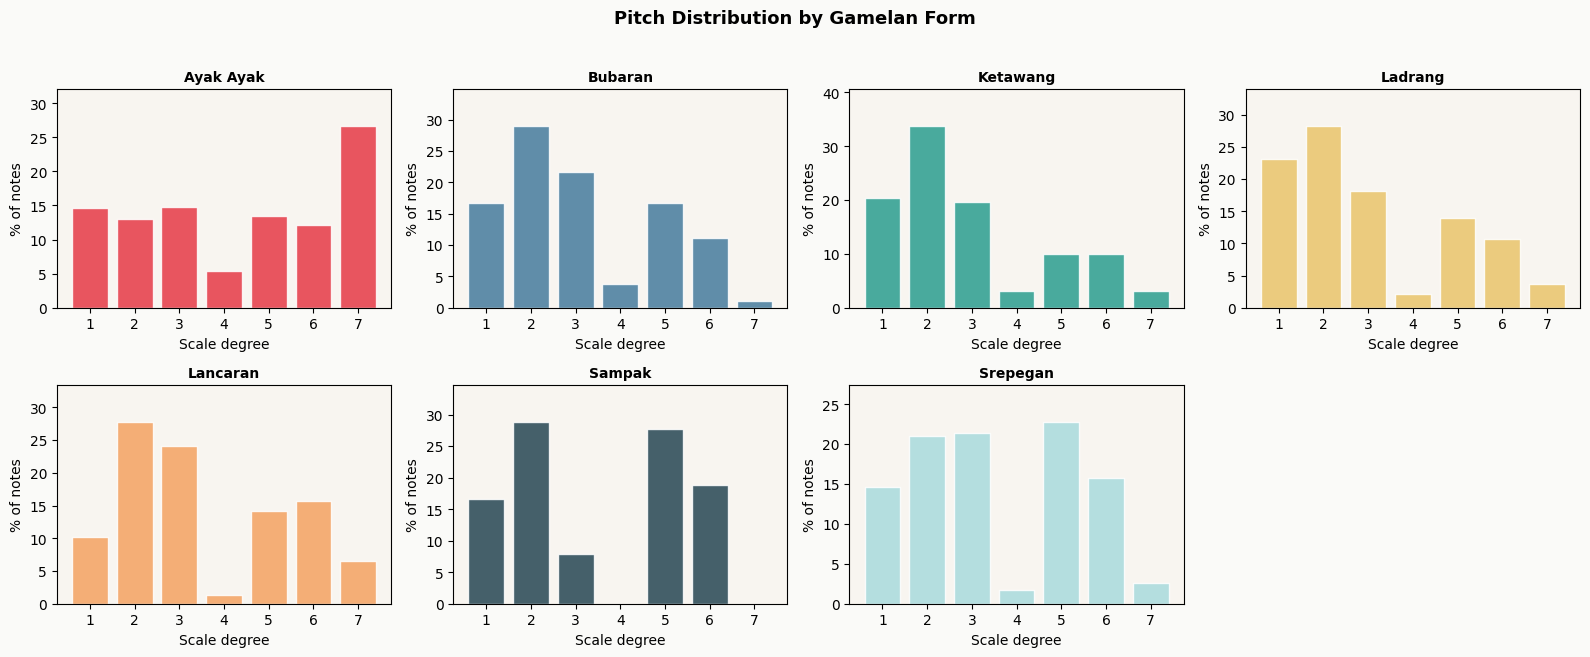

In [7]:
pitches_range = [1, 2, 3, 4, 5, 6, 7]
cols = min(4, len(genres))
rows = math.ceil(len(genres) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.2))
axes = np.array(axes).flatten()

for i, genre in enumerate(genres):
    ax = axes[i]
    pd_g = genre_stats[genre]["pitch_dist"]
    tot = sum(pd_g.values()) or 1
    vals = [pd_g.get(p, 0) / tot * 100 for p in pitches_range]
    ax.bar([str(p) for p in pitches_range], vals, color=colors[genre], alpha=0.85, edgecolor="white")
    ax.set_title(genre, fontsize=10, fontweight="bold")
    ax.set_xlabel("Scale degree")
    ax.set_ylabel("% of notes")
    ax.set_ylim(0, max(vals) * 1.2 if vals else 10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Pitch Distribution by Gamelan Form", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4.2 Register usage

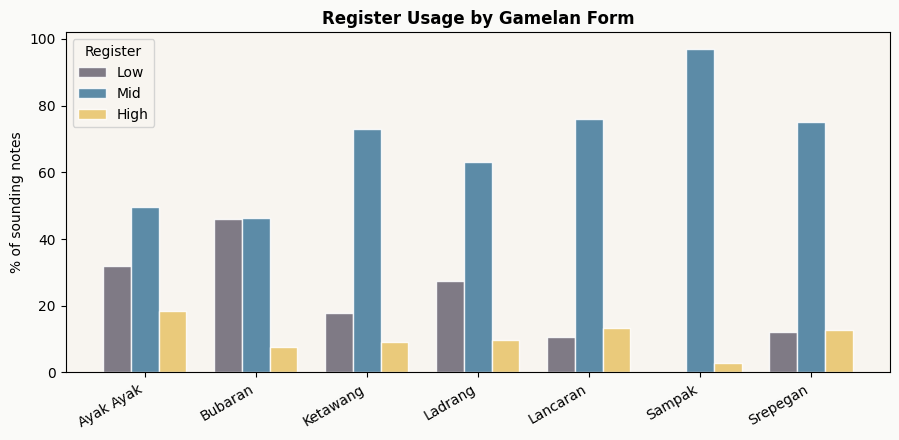

In [8]:
reg_labels = ["Low", "Mid", "High"]
reg_keys = [-1, 0, 1]
reg_colors = ["#6D6875", "#457B9D", "#E9C46A"]

fig, ax = plt.subplots(figsize=(max(8, len(genres) * 1.3), 4.5))
x = np.arange(len(genres))
width = 0.25

for k, (reg, lab, rc) in enumerate(zip(reg_keys, reg_labels, reg_colors)):
    vals = []
    for g in genres:
        rd = genre_stats[g]["register_dist"]
        tot = sum(rd.values()) or 1
        vals.append(rd.get(reg, 0) / tot * 100)
    ax.bar(x + k * width, vals, width, label=lab, color=rc, alpha=0.87, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(genres, rotation=30, ha="right")
ax.legend(title="Register")
ax.set_ylabel("% of sounding notes")
ax.set_title("Register Usage by Gamelan Form", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 4.3 Melodic intervals and gong cycle structure

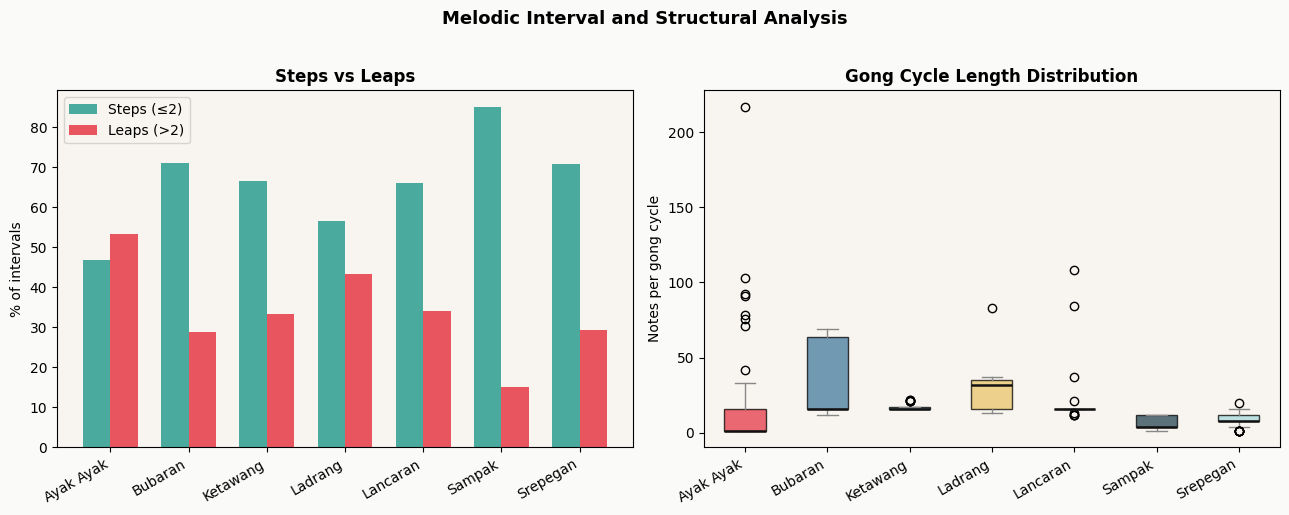

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(genres))
w = 0.35
step_ratios = [genre_stats[g]["interval_stats"]["step_ratio"] * 100 for g in genres]
leap_ratios = [genre_stats[g]["interval_stats"]["leap_ratio"] * 100 for g in genres]
ax1.bar(x - w/2, step_ratios, w, label="Steps (\u22642)", color="#2A9D8F", alpha=0.85)
ax1.bar(x + w/2, leap_ratios, w, label="Leaps (>2)", color="#E63946", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=30, ha="right")
ax1.legend()
ax1.set_ylabel("% of intervals")
ax1.set_title("Steps vs Leaps", fontweight="bold")

gong_data = [genre_stats[g]["gong_densities"] for g in genres if genre_stats[g]["gong_densities"]]
gong_genres = [g for g in genres if genre_stats[g]["gong_densities"]]
if gong_data:
    bp = ax2.boxplot(gong_data, patch_artist=True,
                     medianprops=dict(color="#111", linewidth=1.8),
                     whiskerprops=dict(color="#888"), capprops=dict(color="#888"))
    for patch, g in zip(bp["boxes"], gong_genres):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.75)
    ax2.set_xticklabels(gong_genres, rotation=30, ha="right")
    ax2.set_ylabel("Notes per gong cycle")
    ax2.set_title("Gong Cycle Length Distribution", fontweight="bold")

fig.suptitle("Melodic Interval and Structural Analysis", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4.4 Section occurrence heatmap

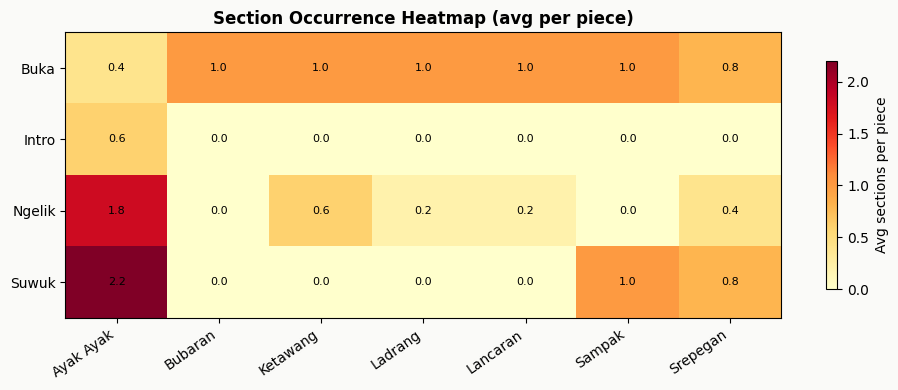

In [10]:
all_sec_types = sorted({s for g in genres for s in genre_stats[g]["section_counts"].keys()})

matrix = np.array([
    [genre_stats[g]["section_counts"].get(s, 0) / (genre_stats[g]["n_pieces"] or 1)
     for g in genres]
    for s in all_sec_types
], dtype=float)

fig, ax = plt.subplots(figsize=(max(9, len(genres) * 1.4), max(4, len(all_sec_types) * 0.7)))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xticks(range(len(genres)))
ax.set_xticklabels(genres, rotation=35, ha="right")
ax.set_yticks(range(len(all_sec_types)))
ax.set_yticklabels(all_sec_types)
for i in range(len(all_sec_types)):
    for j in range(len(genres)):
        ax.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center",
                fontsize=8, color="black" if matrix[i, j] < 3 else "white")
plt.colorbar(im, ax=ax, label="Avg sections per piece", shrink=0.8)
ax.set_title("Section Occurrence Heatmap (avg per piece)", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 4.5 Radar overview

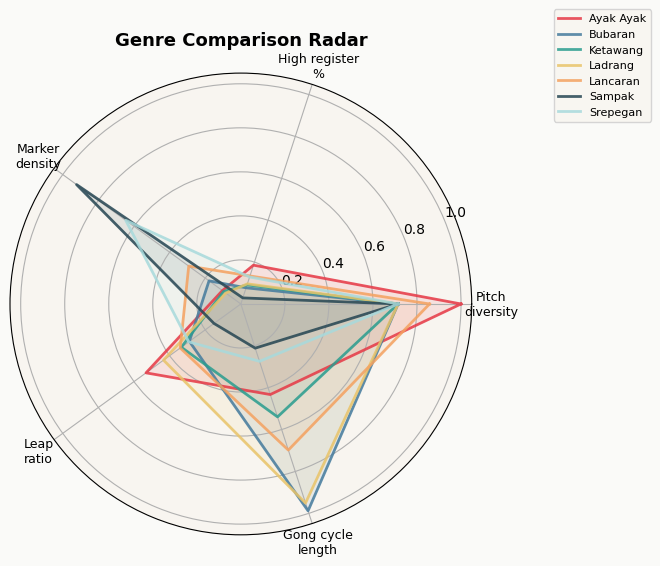

In [11]:
dimensions = ["Pitch\ndiversity", "High register\n%", "Marker\ndensity", "Leap\nratio", "Gong cycle\nlength"]

def extract_radar(g):
    s = genre_stats[g]
    pd_g = s["pitch_dist"]
    total = sum(pd_g.values()) or 1
    pitch_div = len([v for v in pd_g.values() if v / total > 0.05]) / 7
    hi_reg = s["register_dist"].get(1, 0) / (sum(s["register_dist"].values()) or 1)
    marker = min(s["marker_density"] / 2.0, 1.0)
    leap = s["interval_stats"]["leap_ratio"]
    gong_mean = np.mean(s["gong_densities"]) / 32 if s["gong_densities"] else 0
    return [pitch_div, hi_reg, marker, leap, min(gong_mean, 1.0)]

N_dims = len(dimensions)
angles = np.linspace(0, 2 * np.pi, N_dims, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for genre in genres:
    vals = extract_radar(genre) + extract_radar(genre)[:1]
    ax.plot(angles, vals, color=colors[genre], linewidth=2, alpha=0.85, label=genre)
    ax.fill(angles, vals, color=colors[genre], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=9)
ax.set_title("Genre Comparison Radar", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)
fig.tight_layout()
plt.show()

### 4.6 Feature correlation matrix

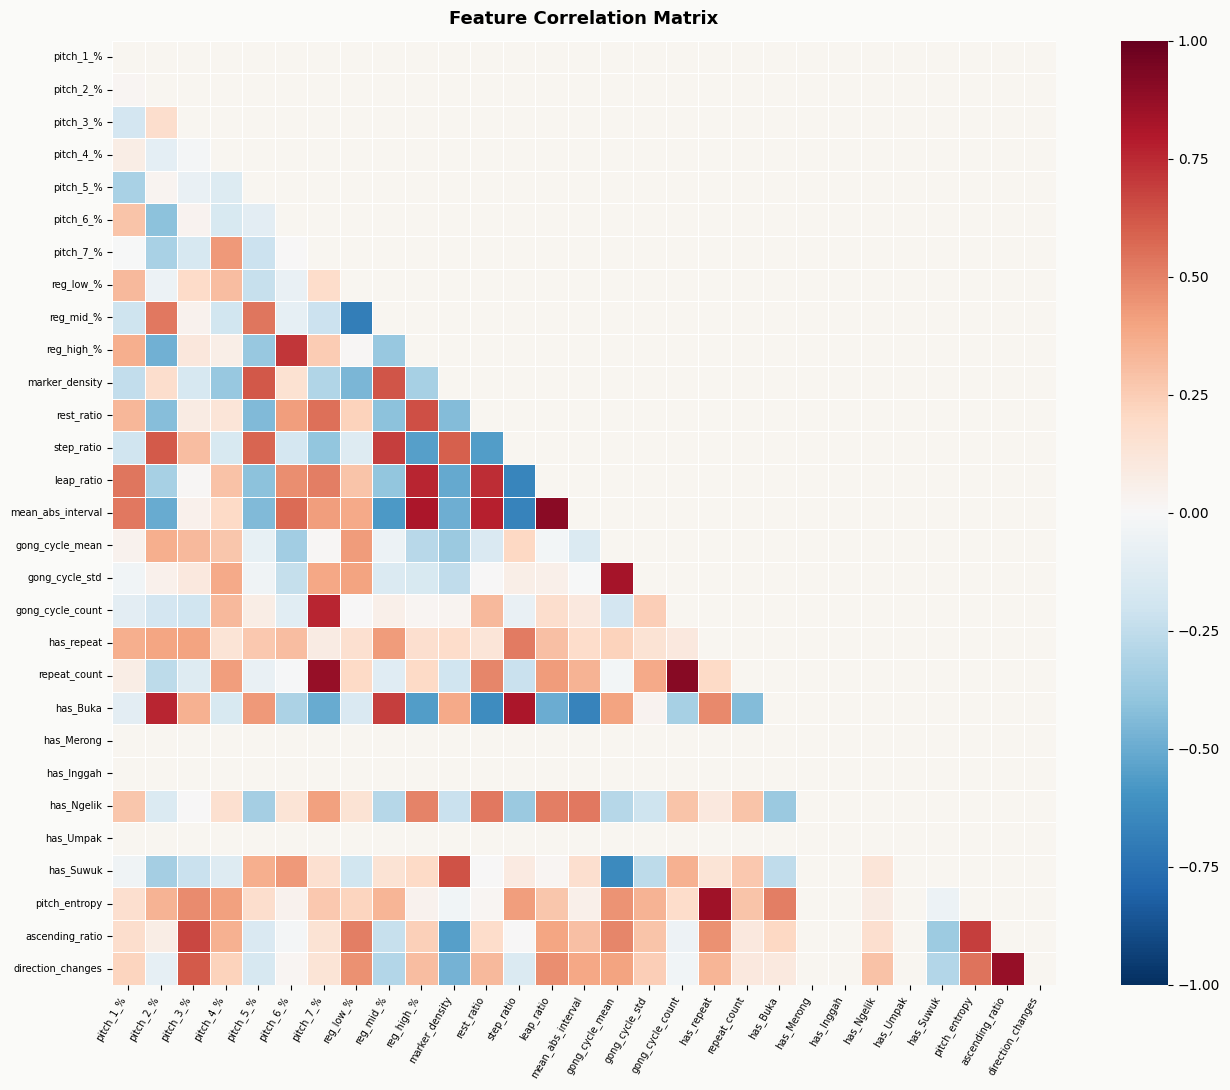

In [12]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df_features[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=False,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(fontsize=7)
fig.tight_layout()
plt.show()

---
## 5. Evaluation Protocol <a id='5-protocol'></a>

Given the small dataset (35 pieces, 7 classes), a single train/test split is unreliable. We use:

1. **Leave-One-Out Cross-Validation (LOOCV) for all six models.** Train on 34 pieces, test on 1, repeat 35 times. This is the **primary metric** for all models — classical and neural alike. For neural models (MLP, CNN), each fold trains from scratch with 300 epochs.
2. **Stratified hold-out split (4 train / 1 test per genre):** Used only for neural-model training curves and embedding visualisation.

In [13]:
# Hold-out split (for neural model training curves / visualisation only)
train_records, test_records = stratified_split(records)
X_train, y_train, _ = to_arrays(train_records, le)
X_test, y_test, _ = to_arrays(test_records, le)

scaler_split = StandardScaler().fit(X_train)
X_train_s = scaler_split.transform(X_train).astype(np.float32)
X_test_s = scaler_split.transform(X_test).astype(np.float32)

loo = LeaveOneOut()

print("Hold-out split (used for visualisation only — primary metric is LOOCV)")
print(f"  {len(train_records)} train / {len(test_records)} test")
print(f"  Train genres: {Counter(y_train)}")
print(f"  Test  genres: {Counter(y_test)}")

  Ayak Ayak: 5 originals → 4 train pieces / 1 test pieces
  Bubaran: 5 originals → 4 train pieces / 1 test pieces
  Ketawang: 5 originals → 4 train pieces / 1 test pieces
  Ladrang: 5 originals → 4 train pieces / 1 test pieces
  Lancaran: 5 originals → 4 train pieces / 1 test pieces
  Sampak: 5 originals → 4 train pieces / 1 test pieces
  Srepegan: 5 originals → 4 train pieces / 1 test pieces
Hold-out split (used for visualisation only — primary metric is LOOCV)
  28 train / 7 test
  Train genres: Counter({np.int64(0): 4, np.int64(1): 4, np.int64(2): 4, np.int64(3): 4, np.int64(4): 4, np.int64(5): 4, np.int64(6): 4})
  Test  genres: Counter({np.int64(0): 1, np.int64(1): 1, np.int64(2): 1, np.int64(3): 1, np.int64(4): 1, np.int64(5): 1, np.int64(6): 1})


---
## 6. Model 1 — Decision Tree <a id='6-dt'></a>

A `DecisionTreeClassifier` with a depth sweep to find the best generalising depth. This model provides full explainability through its decision rules.

In [14]:
best_loo_acc_dt = 0
best_depth_dt = 1

for depth in range(1, 16):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    y_pred_loo = cross_val_predict(dt, X_feat, y, cv=loo)
    acc = accuracy_score(y, y_pred_loo)
    if acc > best_loo_acc_dt:
        best_loo_acc_dt = acc
        best_depth_dt = depth

dt_final = DecisionTreeClassifier(max_depth=best_depth_dt, random_state=42)
y_pred_dt_loo = cross_val_predict(dt_final, X_feat, y, cv=loo)
dt_loo_acc = accuracy_score(y, y_pred_dt_loo)
dt_loo_f1 = f1_score(y, y_pred_dt_loo, average="macro")

print(f"Decision Tree — LOOCV Results")
print(f"  Best depth: {best_depth_dt}")
print(f"  Accuracy:   {dt_loo_acc:.1%}")
print(f"  Macro F1:   {dt_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_dt_loo, target_names=class_names, zero_division=0))

Decision Tree — LOOCV Results
  Best depth: 4
  Accuracy:   62.9%
  Macro F1:   0.629

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.40      0.57         5
     Bubaran       0.40      0.40      0.40         5
    Ketawang       0.60      0.60      0.60         5
     Ladrang       0.80      0.80      0.80         5
    Lancaran       0.33      0.40      0.36         5
      Sampak       1.00      1.00      1.00         5
    Srepegan       0.57      0.80      0.67         5

    accuracy                           0.63        35
   macro avg       0.67      0.63      0.63        35
weighted avg       0.67      0.63      0.63        35



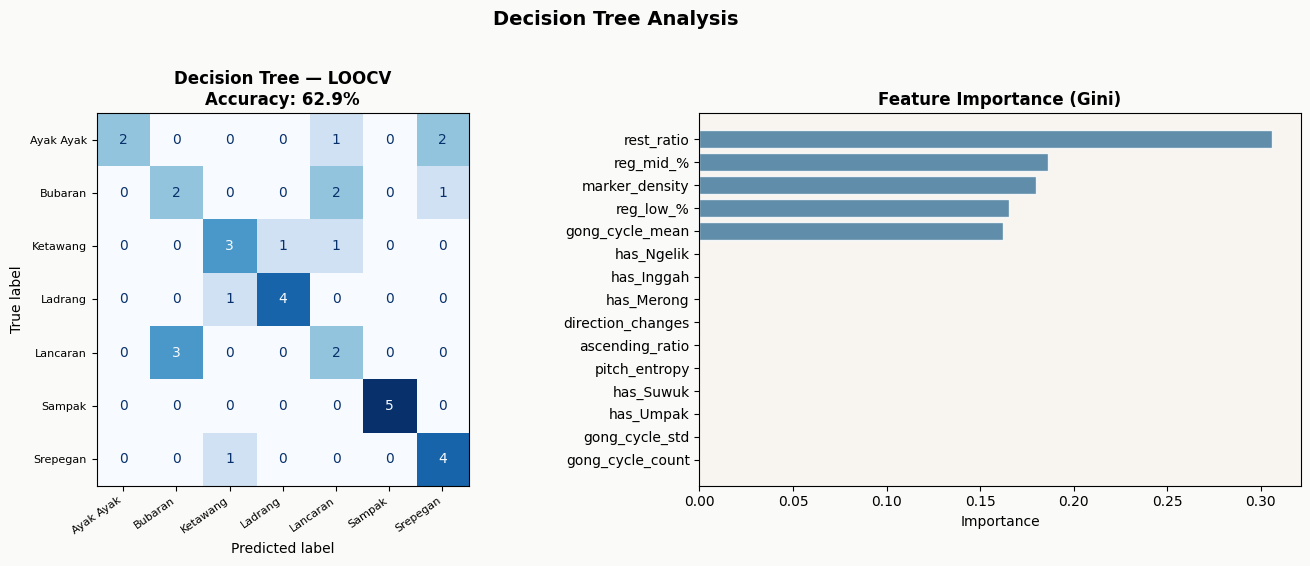

In [15]:
dt_full = DecisionTreeClassifier(max_depth=best_depth_dt, random_state=42)
dt_full.fit(X_feat, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cm_loo = confusion_matrix(y, y_pred_dt_loo)
ConfusionMatrixDisplay(cm_loo, display_labels=class_names).plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Decision Tree — LOOCV\nAccuracy: {dt_loo_acc:.1%}", fontweight="bold")
ax1.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax1.set_yticklabels(class_names, fontsize=8)

imp = dt_full.feature_importances_
top_k = min(15, N_FEATURES)
idx = np.argsort(imp)[::-1][:top_k]
ax2.barh([FEATURE_NAMES[i] for i in idx][::-1], [imp[i] for i in idx][::-1],
         color="#457B9D", alpha=0.85, edgecolor="white")
ax2.set_title("Feature Importance (Gini)", fontweight="bold")
ax2.set_xlabel("Importance")

fig.suptitle("Decision Tree Analysis", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

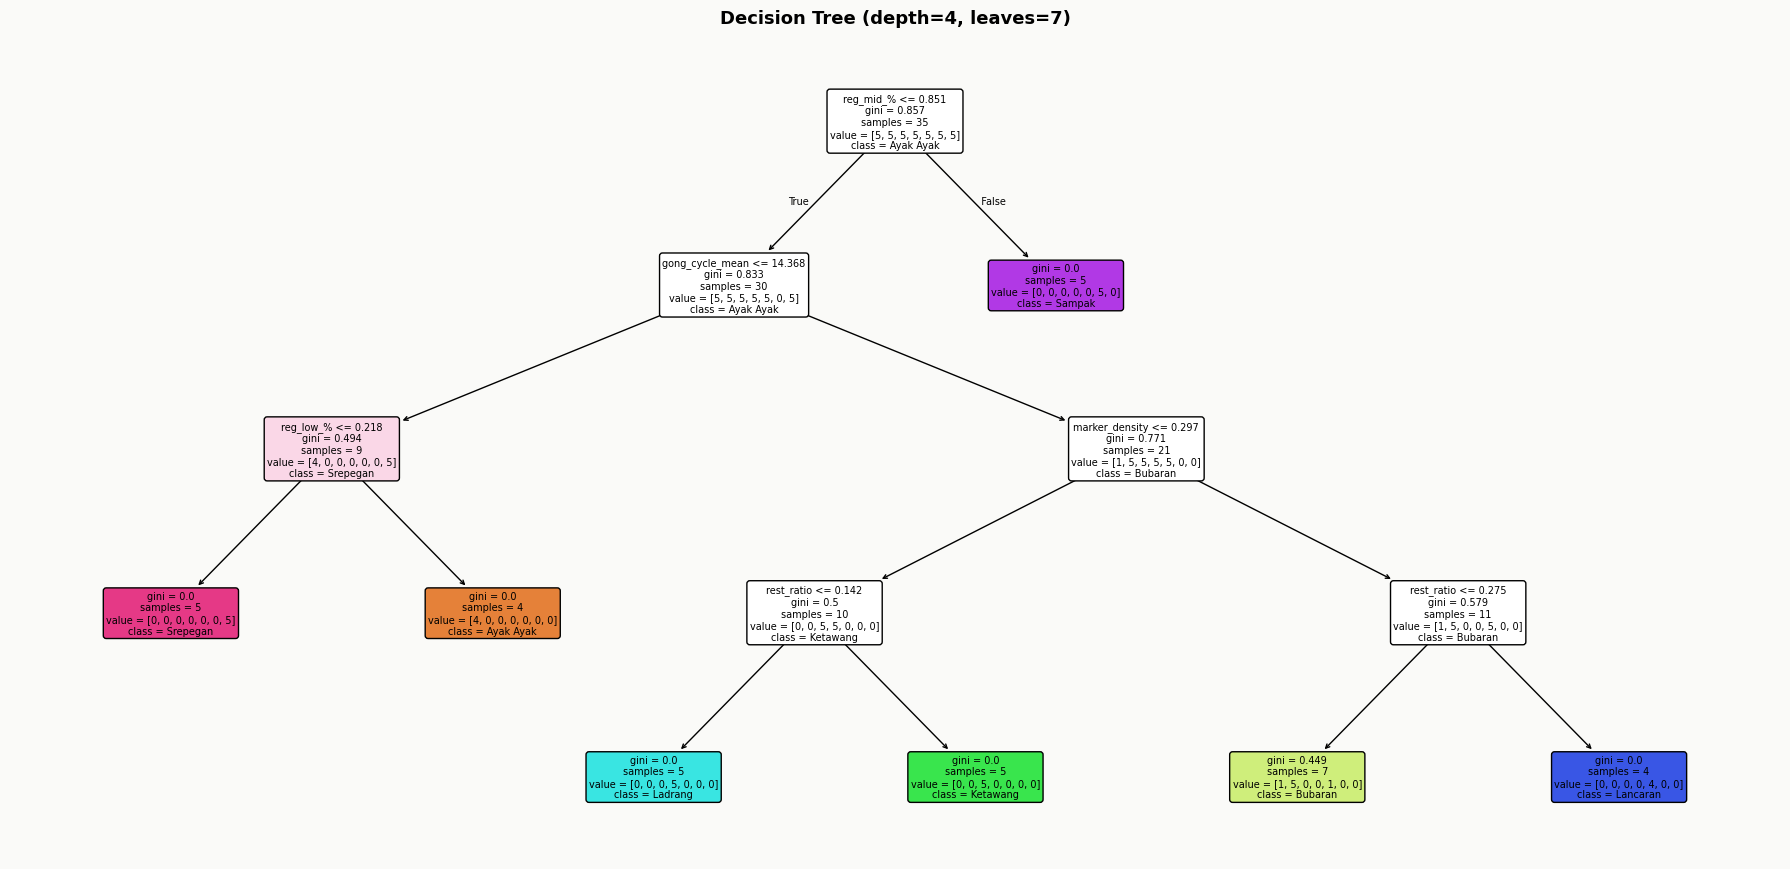


── Decision Rules ──
|--- reg_mid_% <= 0.85
|   |--- gong_cycle_mean <= 14.37
|   |   |--- reg_low_% <= 0.22
|   |   |   |--- class: 6
|   |   |--- reg_low_% >  0.22
|   |   |   |--- class: 0
|   |--- gong_cycle_mean >  14.37
|   |   |--- marker_density <= 0.30
|   |   |   |--- rest_ratio <= 0.14
|   |   |   |   |--- class: 3
|   |   |   |--- rest_ratio >  0.14
|   |   |   |   |--- class: 2
|   |   |--- marker_density >  0.30
|   |   |   |--- rest_ratio <= 0.27
|   |   |   |   |--- class: 1
|   |   |   |--- rest_ratio >  0.27
|   |   |   |   |--- class: 4
|--- reg_mid_% >  0.85
|   |--- class: 5



In [16]:
n_leaves = dt_full.get_n_leaves()
depth = dt_full.get_depth()
fig, ax = plt.subplots(figsize=(max(18, n_leaves * 2.2), max(7, depth * 2.2)))
plot_tree(dt_full, ax=ax, feature_names=FEATURE_NAMES, class_names=class_names,
          filled=True, rounded=True, impurity=True, proportion=False,
          fontsize=max(5, min(9, 50 // max(n_leaves, 1))))
ax.set_title(f"Decision Tree (depth={depth}, leaves={n_leaves})", fontsize=13, fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

print("\n── Decision Rules ──")
print(export_text(dt_full, feature_names=list(FEATURE_NAMES), max_depth=best_depth_dt))

---
## 7. Model 2 — Random Forest <a id='7-rf'></a>

An ensemble of decision trees to reduce variance and improve generalisation.

In [17]:
best_loo_acc_rf = 0
best_n_estimators = 50

for n_est in [50, 100, 200, 300]:
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=best_depth_dt + 2, random_state=42)
    y_pred_loo_rf = cross_val_predict(rf, X_feat, y, cv=loo)
    acc = accuracy_score(y, y_pred_loo_rf)
    if acc > best_loo_acc_rf:
        best_loo_acc_rf = acc
        best_n_estimators = n_est

rf_final = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_depth_dt + 2, random_state=42)
y_pred_rf_loo = cross_val_predict(rf_final, X_feat, y, cv=loo)
rf_loo_acc = accuracy_score(y, y_pred_rf_loo)
rf_loo_f1 = f1_score(y, y_pred_rf_loo, average="macro")

print(f"Random Forest — LOOCV Results")
print(f"  n_estimators: {best_n_estimators}, max_depth: {best_depth_dt + 2}")
print(f"  Accuracy:     {rf_loo_acc:.1%}")
print(f"  Macro F1:     {rf_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_rf_loo, target_names=class_names, zero_division=0))

Random Forest — LOOCV Results
  n_estimators: 100, max_depth: 6
  Accuracy:     68.6%
  Macro F1:     0.686

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.60      0.75         5
     Bubaran       0.43      0.60      0.50         5
    Ketawang       0.67      0.80      0.73         5
     Ladrang       0.80      0.80      0.80         5
    Lancaran       0.67      0.40      0.50         5
      Sampak       0.80      0.80      0.80         5
    Srepegan       0.67      0.80      0.73         5

    accuracy                           0.69        35
   macro avg       0.72      0.69      0.69        35
weighted avg       0.72      0.69      0.69        35



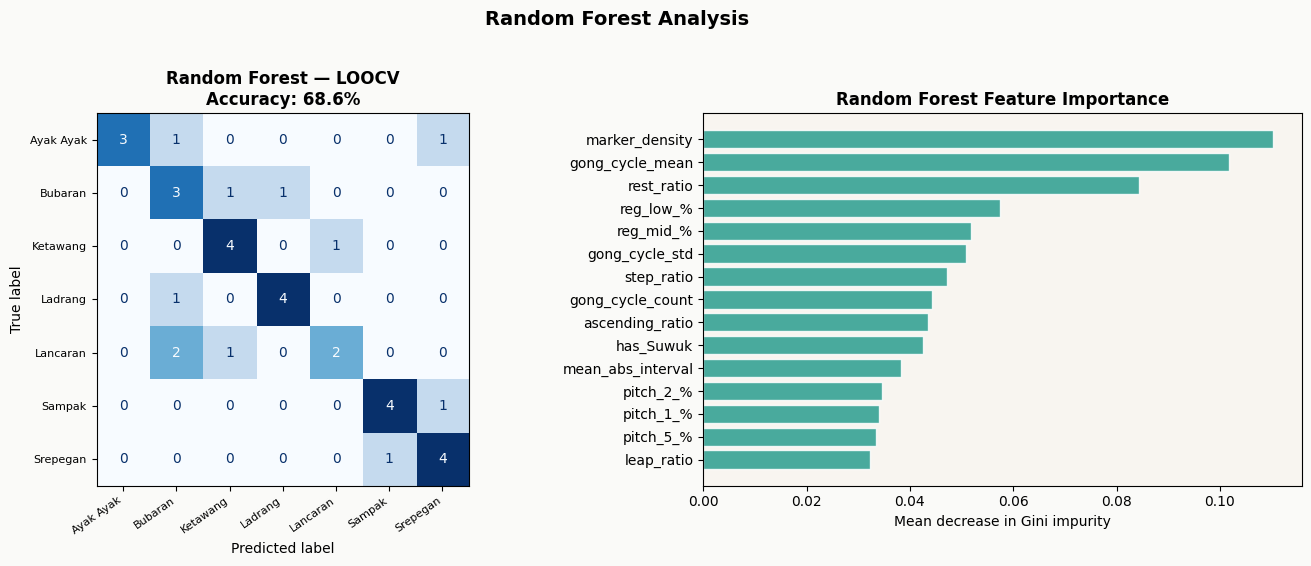

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cm_rf = confusion_matrix(y, y_pred_rf_loo)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Random Forest — LOOCV\nAccuracy: {rf_loo_acc:.1%}", fontweight="bold")
ax1.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax1.set_yticklabels(class_names, fontsize=8)

rf_full = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_depth_dt + 2, random_state=42)
rf_full.fit(X_feat, y)
imp_rf = rf_full.feature_importances_
idx_rf = np.argsort(imp_rf)[::-1][:top_k]
ax2.barh([FEATURE_NAMES[i] for i in idx_rf][::-1], [imp_rf[i] for i in idx_rf][::-1],
         color="#2A9D8F", alpha=0.85, edgecolor="white")
ax2.set_title("Random Forest Feature Importance", fontweight="bold")
ax2.set_xlabel("Mean decrease in Gini impurity")

fig.suptitle("Random Forest Analysis", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## 8. Model 3 — Support Vector Machine <a id='8-svm'></a>

SVM with RBF kernel, operating on standardised features.

In [19]:
best_loo_acc_svm = 0
best_C = 1.0

for C in [0.1, 1.0, 10.0, 100.0]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(C=C, kernel="rbf", gamma="scale", random_state=42)),
    ])
    y_pred_loo_svm = cross_val_predict(pipe, X_feat, y, cv=loo)
    acc = accuracy_score(y, y_pred_loo_svm)
    if acc > best_loo_acc_svm:
        best_loo_acc_svm = acc
        best_C = C

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(C=best_C, kernel="rbf", gamma="scale", random_state=42)),
])
y_pred_svm_loo = cross_val_predict(svm_pipe, X_feat, y, cv=loo)
svm_loo_acc = accuracy_score(y, y_pred_svm_loo)
svm_loo_f1 = f1_score(y, y_pred_svm_loo, average="macro")

print(f"SVM (RBF) — LOOCV Results  (Pipeline: StandardScaler → SVC)")
print(f"  C:        {best_C}")
print(f"  Accuracy: {svm_loo_acc:.1%}")
print(f"  Macro F1: {svm_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_svm_loo, target_names=class_names, zero_division=0))

SVM (RBF) — LOOCV Results  (Pipeline: StandardScaler → SVC)
  C:        10.0
  Accuracy: 62.9%
  Macro F1: 0.628

              precision    recall  f1-score   support

   Ayak Ayak       0.80      0.80      0.80         5
     Bubaran       0.50      0.60      0.55         5
    Ketawang       0.33      0.20      0.25         5
     Ladrang       0.29      0.40      0.33         5
    Lancaran       0.75      0.60      0.67         5
      Sampak       1.00      1.00      1.00         5
    Srepegan       0.80      0.80      0.80         5

    accuracy                           0.63        35
   macro avg       0.64      0.63      0.63        35
weighted avg       0.64      0.63      0.63        35



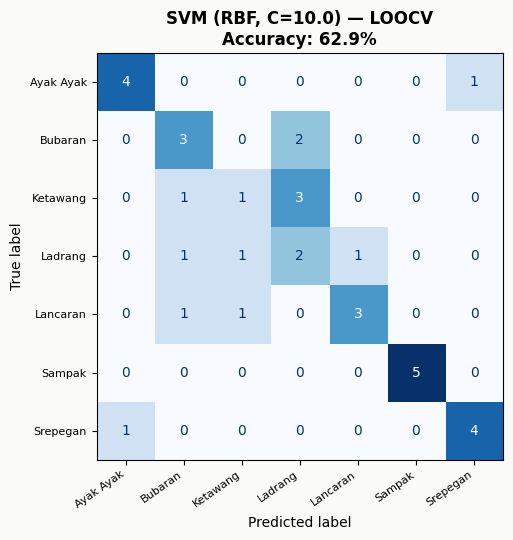

In [20]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm_svm = confusion_matrix(y, y_pred_svm_loo)
ConfusionMatrixDisplay(cm_svm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"SVM (RBF, C={best_C}) — LOOCV\nAccuracy: {svm_loo_acc:.1%}", fontweight="bold")
ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
fig.tight_layout()
plt.show()

---
## 9. Model 4 — k-Nearest Neighbors <a id='9-knn'></a>

In [21]:
best_loo_acc_knn = 0
best_k = 3

for k in [1, 3, 5, 7]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k, weights='distance')),
    ])
    y_pred_loo_knn = cross_val_predict(pipe, X_feat, y, cv=loo)
    acc = accuracy_score(y, y_pred_loo_knn)
    if acc > best_loo_acc_knn:
        best_loo_acc_knn = acc
        best_k = k

knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k, weights='distance')),
])
y_pred_knn_loo = cross_val_predict(knn_pipe, X_feat, y, cv=loo)
knn_loo_acc = accuracy_score(y, y_pred_knn_loo)
knn_loo_f1 = f1_score(y, y_pred_knn_loo, average="macro")

print(f"KNN — LOOCV Results  (Pipeline: StandardScaler → KNN, weights='distance')")
print(f"  k:        {best_k}")
print(f"  Accuracy: {knn_loo_acc:.1%}")
print(f"  Macro F1: {knn_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_knn_loo, target_names=class_names, zero_division=0))

KNN — LOOCV Results  (Pipeline: StandardScaler → KNN, weights='distance')
  k:        5
  Accuracy: 57.1%
  Macro F1: 0.575

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.60      0.75         5
     Bubaran       0.75      0.60      0.67         5
    Ketawang       0.40      0.40      0.40         5
     Ladrang       0.22      0.40      0.29         5
    Lancaran       0.50      0.20      0.29         5
      Sampak       0.83      1.00      0.91         5
    Srepegan       0.67      0.80      0.73         5

    accuracy                           0.57        35
   macro avg       0.62      0.57      0.57        35
weighted avg       0.62      0.57      0.57        35



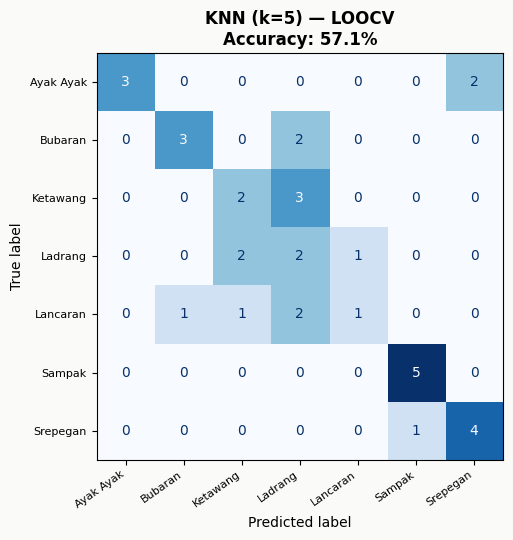

In [22]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm_knn = confusion_matrix(y, y_pred_knn_loo)
ConfusionMatrixDisplay(cm_knn, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"KNN (k={best_k}) — LOOCV\nAccuracy: {knn_loo_acc:.1%}", fontweight="bold")
ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
fig.tight_layout()
plt.show()

---
## 10. Model 5 — MLP (Neural Network) <a id='10-mlp'></a>

A two-hidden-layer PyTorch MLP operating on z-scored features.

**Architecture:** Input(29) → Linear(64) → BN → ReLU → Dropout → Linear(32) → BN → ReLU → Dropout → Linear(7)

Model and training loop imported from `src.gamelan_mlp`.

In [23]:
print("Training MLP (src.gamelan_mlp)...\n")
mlp_model, mlp_history = train_mlp(
    X_train_s, y_train,
    X_test_s, y_test,
    n_classes,
)

mlp_model.eval()
with torch.no_grad():
    mlp_proba = torch.softmax(mlp_model(torch.tensor(X_test_s)), dim=1).numpy()
    mlp_pred = mlp_proba.argmax(axis=1)

mlp_holdout_acc = accuracy_score(y_test, mlp_pred)
mlp_holdout_f1 = f1_score(y_test, mlp_pred, average="macro", zero_division=0)
mlp_best_test_acc = max(mlp_history["test_acc"])

test_ids = sorted(set(y_test))
test_names = [le.classes_[i] for i in test_ids]

print(f"\nMLP — Hold-out Results")
print(f"  Final test accuracy: {mlp_holdout_acc:.1%}")
print(f"  Best test accuracy:  {mlp_best_test_acc:.1%}")
print(f"  Macro F1:            {mlp_holdout_f1:.3f}")
print()
print(classification_report(y_test, mlp_pred, target_names=test_names, zero_division=0))

Training MLP (src.gamelan_mlp)...

  epoch    1  train loss 1.9276  acc 17.9%  │  test loss 2.0024  acc 0.0%
  epoch  100  train loss 0.0555  acc 100.0%  │  test loss 2.4218  acc 42.9%
  epoch  200  train loss 0.0163  acc 100.0%  │  test loss 3.2215  acc 42.9%
  epoch  300  train loss 0.0079  acc 100.0%  │  test loss 3.5656  acc 42.9%
  epoch  400  train loss 0.0053  acc 100.0%  │  test loss 3.5183  acc 42.9%
  epoch  500  train loss 0.0046  acc 100.0%  │  test loss 3.6876  acc 57.1%
  epoch  600  train loss 0.0042  acc 100.0%  │  test loss 3.7111  acc 57.1%

MLP — Hold-out Results
  Final test accuracy: 57.1%
  Best test accuracy:  57.1%
  Macro F1:            0.476

              precision    recall  f1-score   support

   Ayak Ayak       1.00      1.00      1.00         1
     Bubaran       0.50      1.00      0.67         1
    Ketawang       0.00      0.00      0.00         1
     Ladrang       0.00      0.00      0.00         1
    Lancaran       0.50      1.00      0.67         

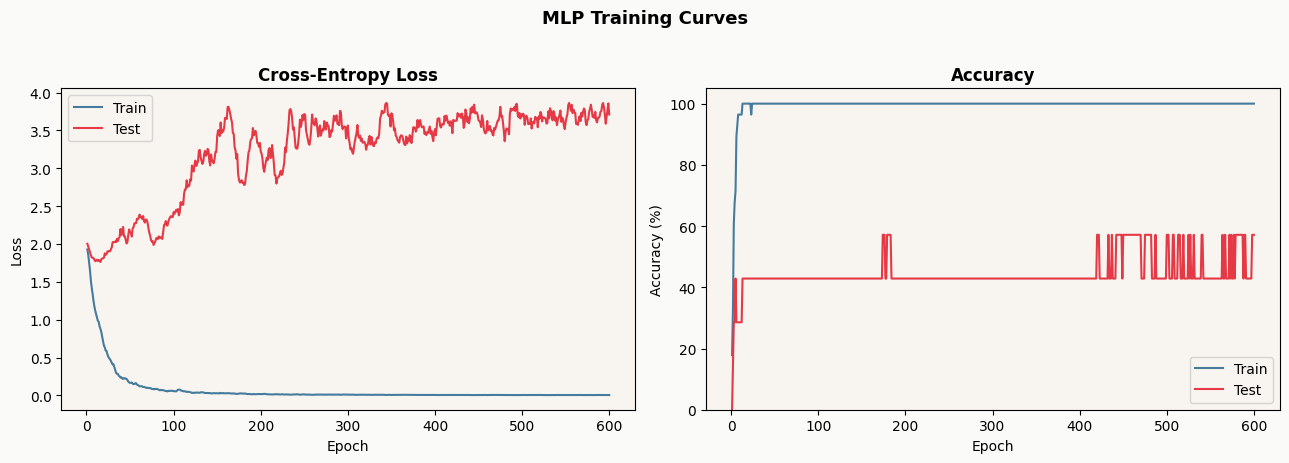

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(mlp_history["train_loss"]) + 1)

ax1.plot(epochs, mlp_history["train_loss"], color="#457B9D", lw=1.5, label="Train")
ax1.plot(epochs, mlp_history["test_loss"], color="#E63946", lw=1.5, label="Test")
ax1.legend(); ax1.set_title("Cross-Entropy Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(epochs, [a * 100 for a in mlp_history["train_acc"]], color="#457B9D", lw=1.5, label="Train")
ax2.plot(epochs, [a * 100 for a in mlp_history["test_acc"]], color="#E63946", lw=1.5, label="Test")
ax2.set_ylim(0, 105); ax2.legend()
ax2.set_title("Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")

fig.suptitle("MLP Training Curves", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

In [25]:
print("MLP — Leave-One-Out CV (35 folds × 300 epochs)...\n")

y_pred_mlp_loo = np.zeros(len(y), dtype=int)

for fold, (tr_idx, te_idx) in enumerate(loo.split(X_feat)):
    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_feat[tr_idx]).astype(np.float32)
    X_te_s_f = sc.transform(X_feat[te_idx]).astype(np.float32)

    model_f, _ = train_mlp(X_tr_s, y[tr_idx], X_te_s_f, y[te_idx], n_classes,
                            n_epochs=300, verbose=False)

    model_f.eval()
    with torch.no_grad():
        y_pred_mlp_loo[te_idx] = model_f(torch.tensor(X_te_s_f)).argmax(1).numpy()

    if (fold + 1) % 10 == 0 or fold == 0:
        print(f"  Fold {fold+1:2d}/35")

mlp_loo_acc = accuracy_score(y, y_pred_mlp_loo)
mlp_loo_f1 = f1_score(y, y_pred_mlp_loo, average="macro")

print(f"\nMLP — LOOCV Results")
print(f"  Accuracy: {mlp_loo_acc:.1%}")
print(f"  Macro F1: {mlp_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_mlp_loo, target_names=class_names, zero_division=0))

MLP — Leave-One-Out CV (35 folds × 300 epochs)...

  Fold  1/35
  Fold 10/35
  Fold 20/35
  Fold 30/35

MLP — LOOCV Results
  Accuracy: 62.9%
  Macro F1: 0.627

              precision    recall  f1-score   support

   Ayak Ayak       1.00      1.00      1.00         5
     Bubaran       0.43      0.60      0.50         5
    Ketawang       0.00      0.00      0.00         5
     Ladrang       0.29      0.40      0.33         5
    Lancaran       0.75      0.60      0.67         5
      Sampak       1.00      1.00      1.00         5
    Srepegan       1.00      0.80      0.89         5

    accuracy                           0.63        35
   macro avg       0.64      0.63      0.63        35
weighted avg       0.64      0.63      0.63        35



---
## 11. Model 6 — 1D CNN <a id='11-cnn'></a>

Operates on **raw note sequences** — no feature engineering. Each note is encoded as a 7-dim vector (pitch, octave, kenong, kethuk, gong, kempyang, is_rest).

Model and training loop imported from `src.gamelan_cnn`. Sequence loading uses `src.data.load_corpus_sequences()`.

In [26]:
print("Loading corpus (raw sequences for CNN)...\n")
seq_records = load_corpus_sequences(DATASET_ROOT)

seq_lengths = [r["seq_len"] for r in seq_records]
pad_len = int(np.percentile([l for l in seq_lengths if l > 0], 95))
print(f"\nSequence lengths — min: {min(seq_lengths)}, max: {max(seq_lengths)}, "
      f"mean: {np.mean(seq_lengths):.0f}, p95 (pad_len): {pad_len}")

seq_train, seq_test = stratified_split(seq_records)
X_seq_train, y_seq_train, le_seq = to_tensors(seq_train, pad_len)
X_seq_test, y_seq_test, _ = to_tensors(seq_test, pad_len, le_seq)

print(f"\nCNN input shape: {tuple(X_seq_train.shape)} (N, channels={N_DIMS}, time={pad_len})")
print(f"Train: {len(seq_train)} / Test: {len(seq_test)}")

Loading corpus (raw sequences for CNN)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura  (94 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura  (3410 events)
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga  (196 events)
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura  (140 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang  (80 events)
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem  (85 events)
  ✅  Bubaran / Bubaran Purwaka Pelog Nem  (81 events)
  ✅  Bubaran / Bubaran Sembunggilang Slendro Sanga  (85 events)
  ✅  Bubaran / Bubaran Udan Mas Pelog Barang  (80 events)
  ✅  Ketawang / Ketawang Ibu Pretiwi Pelog Nem  (113 events)
  ✅  Ketawang / Ketawang Kinanthi Pawukir Slendro Manyura  (86 events)
  ✅  Ketawang / Ketawang Kinanthi Sandhung Slendro Manyura  (96 events)
  ✅  Ketawang / Ketawang Langen Gita Pelog Barang  (86 events)
  ✅  Ketawang / Ketawang Subakastawa Slendro Sanga  (85 events)
  ✅  Ladrang 

In [27]:
print("Training 1D-CNN (src.gamelan_cnn)...\n")
cnn_model, cnn_history = train_cnn(X_seq_train, y_seq_train, X_seq_test, y_seq_test, n_classes)

cnn_model.eval()
with torch.no_grad():
    cnn_proba = torch.softmax(cnn_model(X_seq_test), dim=1).numpy()
    cnn_pred = cnn_proba.argmax(axis=1)

y_seq_test_np = y_seq_test.numpy()
cnn_holdout_acc = accuracy_score(y_seq_test_np, cnn_pred)
cnn_holdout_f1 = f1_score(y_seq_test_np, cnn_pred, average="macro", zero_division=0)
cnn_best_test_acc = max(cnn_history["test_acc"])

cnn_test_ids = sorted(set(y_seq_test_np))
cnn_test_names = [le_seq.classes_[i] for i in cnn_test_ids]

print(f"\n1D-CNN — Hold-out Results")
print(f"  Final test accuracy: {cnn_holdout_acc:.1%}")
print(f"  Best test accuracy:  {cnn_best_test_acc:.1%}")
print(f"  Macro F1:            {cnn_holdout_f1:.3f}")
print()
print(classification_report(y_seq_test_np, cnn_pred, target_names=cnn_test_names, zero_division=0))

Training 1D-CNN (src.gamelan_cnn)...

  epoch    1  train loss 1.9451  acc 14.3%  │  test loss 1.9433  acc 14.3%
  epoch  100  train loss 0.0109  acc 100.0%  │  test loss 0.4505  acc 85.7%
  epoch  200  train loss 0.0024  acc 100.0%  │  test loss 0.4623  acc 85.7%
  epoch  300  train loss 0.0016  acc 100.0%  │  test loss 0.4210  acc 85.7%
  epoch  400  train loss 0.0009  acc 100.0%  │  test loss 0.4755  acc 85.7%
  epoch  500  train loss 0.0008  acc 100.0%  │  test loss 0.4906  acc 85.7%
  epoch  600  train loss 0.0008  acc 100.0%  │  test loss 0.4835  acc 85.7%

1D-CNN — Hold-out Results
  Final test accuracy: 85.7%
  Best test accuracy:  85.7%
  Macro F1:            0.810

              precision    recall  f1-score   support

   Ayak Ayak       1.00      1.00      1.00         1
     Bubaran       1.00      1.00      1.00         1
    Ketawang       1.00      1.00      1.00         1
     Ladrang       0.50      1.00      0.67         1
    Lancaran       1.00      1.00      1.00  

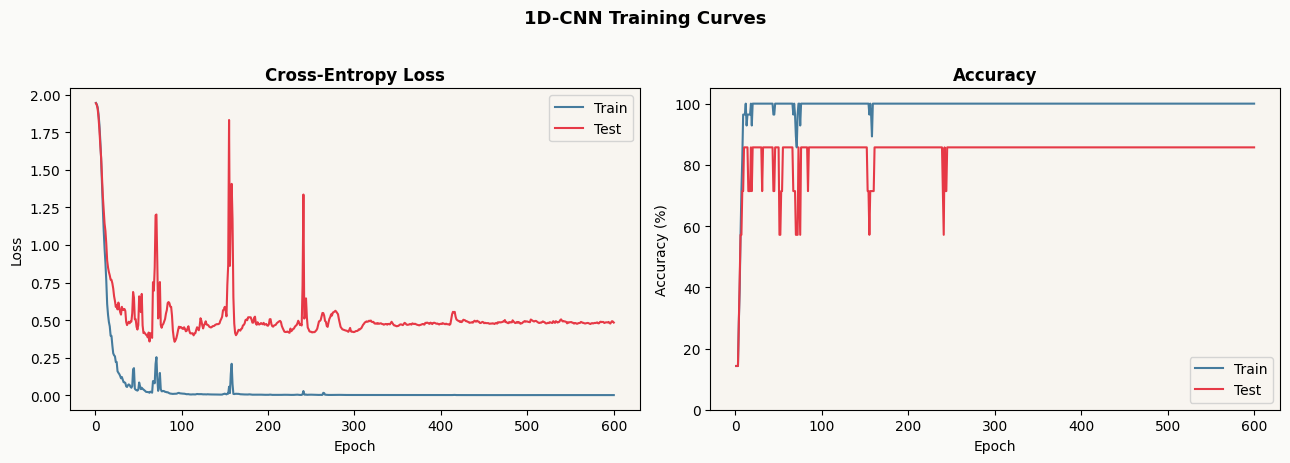

In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(cnn_history["train_loss"]) + 1)

ax1.plot(epochs, cnn_history["train_loss"], color="#457B9D", lw=1.5, label="Train")
ax1.plot(epochs, cnn_history["test_loss"], color="#E63946", lw=1.5, label="Test")
ax1.legend(); ax1.set_title("Cross-Entropy Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(epochs, [a * 100 for a in cnn_history["train_acc"]], color="#457B9D", lw=1.5, label="Train")
ax2.plot(epochs, [a * 100 for a in cnn_history["test_acc"]], color="#E63946", lw=1.5, label="Test")
ax2.set_ylim(0, 105); ax2.legend()
ax2.set_title("Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")

fig.suptitle("1D-CNN Training Curves", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

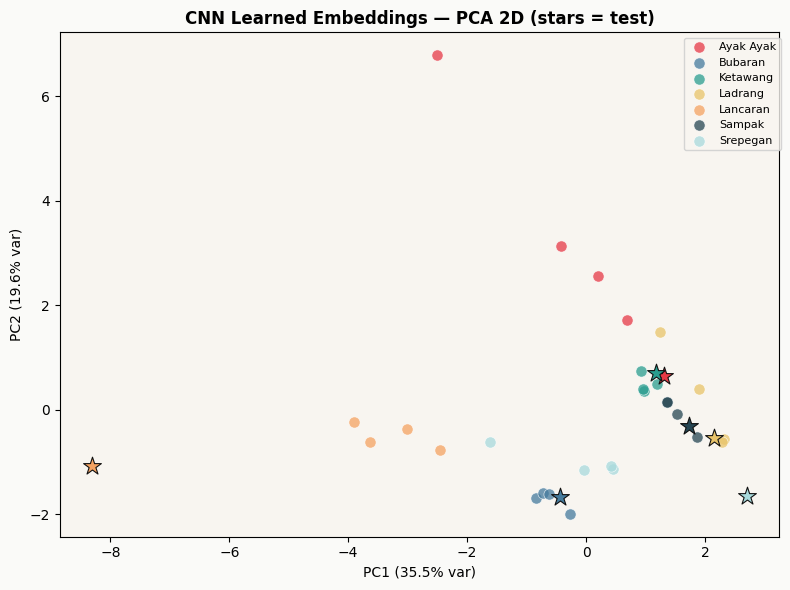

In [29]:
cnn_model.eval()
with torch.no_grad():
    emb_tr = cnn_model.feature_map(X_seq_train).numpy()
    emb_te = cnn_model.feature_map(X_seq_test).numpy()

all_emb = np.vstack([emb_tr, emb_te])
centered = all_emb - all_emb.mean(axis=0)
_, S, Vt = np.linalg.svd(centered, full_matrices=False)
pcs = centered @ Vt[:2].T
var_exp = S[:2] ** 2 / (S ** 2).sum() * 100
pcs_tr, pcs_te = pcs[:len(emb_tr)], pcs[len(emb_tr):]

fig, ax = plt.subplots(figsize=(8, 6))
y_tr_np, y_te_np = y_seq_train.numpy(), y_seq_test_np
for k, genre in enumerate(le_seq.classes_):
    c = PALETTE[k % len(PALETTE)]
    ax.scatter(pcs_tr[y_tr_np == k, 0], pcs_tr[y_tr_np == k, 1], color=c, s=65, alpha=0.75,
               edgecolors="white", linewidths=0.5, label=genre, zorder=3)
    if np.any(y_te_np == k):
        ax.scatter(pcs_te[y_te_np == k, 0], pcs_te[y_te_np == k, 1], color=c, s=180, marker="*",
                   edgecolors="#111", linewidths=0.8, zorder=5)

ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1))
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% var)")
ax.set_title("CNN Learned Embeddings — PCA 2D (stars = test)", fontweight="bold")
fig.tight_layout()
plt.show()

In [30]:
print("1D-CNN — Leave-One-Out CV (35 folds × 300 epochs)...\n")

X_seq_all, y_seq_all, le_seq_all = to_tensors(seq_records, pad_len)
y_seq_all_np = y_seq_all.numpy()

y_pred_cnn_loo = np.zeros(len(y_seq_all_np), dtype=int)

for fold, (tr_idx, te_idx) in enumerate(LeaveOneOut().split(X_seq_all)):
    X_tr_c, y_tr_c = X_seq_all[tr_idx], y_seq_all[tr_idx]
    X_te_c, y_te_c = X_seq_all[te_idx], y_seq_all[te_idx]

    model_c, _ = train_cnn(X_tr_c, y_tr_c, X_te_c, y_te_c, n_classes,
                            n_epochs=300, verbose=False)

    model_c.eval()
    with torch.no_grad():
        y_pred_cnn_loo[te_idx] = model_c(X_te_c).argmax(1).numpy()

    if (fold + 1) % 10 == 0 or fold == 0:
        print(f"  Fold {fold+1:2d}/35")

cnn_loo_acc = accuracy_score(y_seq_all_np, y_pred_cnn_loo)
cnn_loo_f1 = f1_score(y_seq_all_np, y_pred_cnn_loo, average="macro")

print(f"\n1D-CNN — LOOCV Results")
print(f"  Accuracy: {cnn_loo_acc:.1%}")
print(f"  Macro F1: {cnn_loo_f1:.3f}")
print()
print(classification_report(y_seq_all_np, y_pred_cnn_loo,
                            target_names=list(le_seq_all.classes_), zero_division=0))

1D-CNN — Leave-One-Out CV (35 folds × 300 epochs)...

  Fold  1/35
  Fold 10/35
  Fold 20/35
  Fold 30/35

1D-CNN — LOOCV Results
  Accuracy: 88.6%
  Macro F1: 0.885

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.80      0.89         5
     Bubaran       0.83      1.00      0.91         5
    Ketawang       0.83      1.00      0.91         5
     Ladrang       0.80      0.80      0.80         5
    Lancaran       1.00      0.80      0.89         5
      Sampak       1.00      1.00      1.00         5
    Srepegan       0.80      0.80      0.80         5

    accuracy                           0.89        35
   macro avg       0.90      0.89      0.89        35
weighted avg       0.90      0.89      0.89        35



---
## 12. Model Comparison <a id='12-comparison'></a>

In [31]:
results = pd.DataFrame([
    {"Model": "Decision Tree", "Evaluation": "LOOCV", "Accuracy": dt_loo_acc, "Macro F1": dt_loo_f1,
     "Input": "29 features", "Best Hyperparams": f"depth={best_depth_dt}"},
    {"Model": "Random Forest", "Evaluation": "LOOCV", "Accuracy": rf_loo_acc, "Macro F1": rf_loo_f1,
     "Input": "29 features", "Best Hyperparams": f"n_est={best_n_estimators}"},
    {"Model": "SVM (RBF)", "Evaluation": "LOOCV", "Accuracy": svm_loo_acc, "Macro F1": svm_loo_f1,
     "Input": "29 features (Pipeline)", "Best Hyperparams": f"C={best_C}"},
    {"Model": "KNN", "Evaluation": "LOOCV", "Accuracy": knn_loo_acc, "Macro F1": knn_loo_f1,
     "Input": "29 features (Pipeline)", "Best Hyperparams": f"k={best_k}"},
    {"Model": "MLP", "Evaluation": "LOOCV", "Accuracy": mlp_loo_acc, "Macro F1": mlp_loo_f1,
     "Input": "29 features (scaled)", "Best Hyperparams": "lr=3e-3, dropout=0.3"},
    {"Model": "1D CNN", "Evaluation": "LOOCV", "Accuracy": cnn_loo_acc, "Macro F1": cnn_loo_f1,
     "Input": f"Raw sequences (7\u00d7{pad_len})", "Best Hyperparams": "lr=3e-3, dropout=0.3"},
])

results_display = results.copy()
results_display["Accuracy"] = results["Accuracy"].map("{:.1%}".format)
results_display["Macro F1"] = results["Macro F1"].map("{:.3f}".format)

print("=" * 90)
print("MODEL COMPARISON — All models evaluated with LOOCV (35 folds)")
print("=" * 90)
print(results_display.to_string(index=False))
print("=" * 90)

results_display

MODEL COMPARISON — All models evaluated with LOOCV (35 folds)
        Model Evaluation Accuracy Macro F1                  Input     Best Hyperparams
Decision Tree      LOOCV    62.9%    0.629            29 features              depth=4
Random Forest      LOOCV    68.6%    0.686            29 features            n_est=100
    SVM (RBF)      LOOCV    62.9%    0.628 29 features (Pipeline)               C=10.0
          KNN      LOOCV    57.1%    0.575 29 features (Pipeline)                  k=5
          MLP      LOOCV    62.9%    0.627   29 features (scaled) lr=3e-3, dropout=0.3
       1D CNN      LOOCV    88.6%    0.885  Raw sequences (7×183) lr=3e-3, dropout=0.3


,Model,Evaluation,Accuracy,Macro F1,Input,Best Hyperparams
0,Decision Tree,LOOCV,62.9%,0.629,29 features,depth=4
1,Random Forest,LOOCV,68.6%,0.686,29 features,n_est=100
2,SVM (RBF),LOOCV,62.9%,0.628,29 features (Pipeline),C=10.0
3,KNN,LOOCV,57.1%,0.575,29 features (Pipeline),k=5
4,MLP,LOOCV,62.9%,0.627,29 features (scaled),"lr=3e-3, dropout=0.3"
5,1D CNN,LOOCV,88.6%,0.885,Raw sequences (7×183),"lr=3e-3, dropout=0.3"


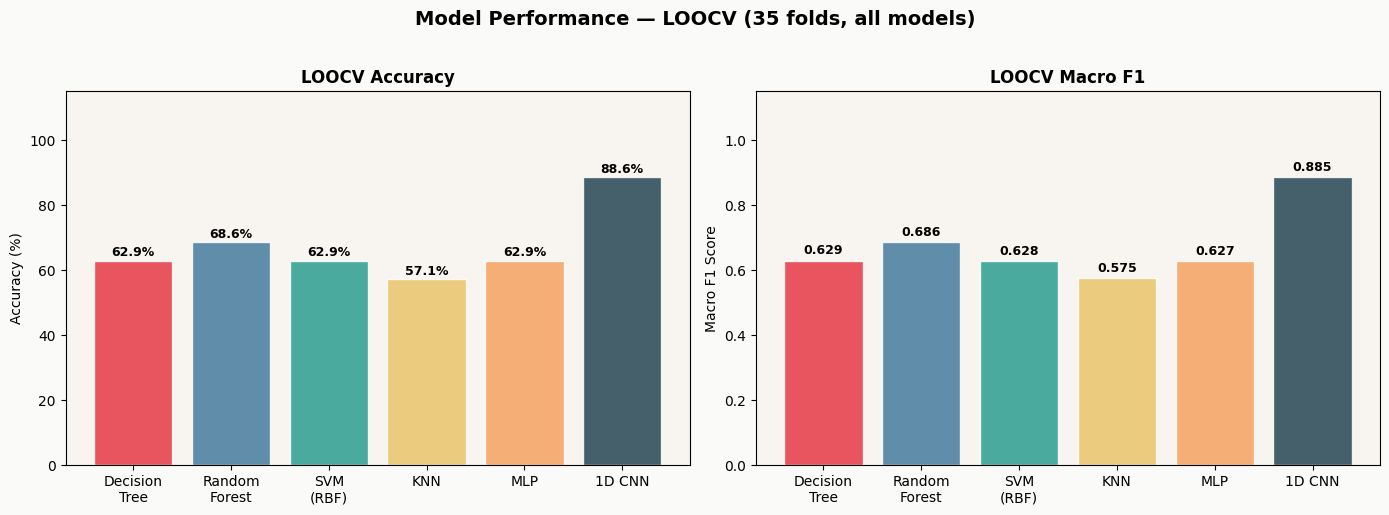

In [32]:
model_names = ["Decision\nTree", "Random\nForest", "SVM\n(RBF)", "KNN", "MLP", "1D CNN"]
accuracies = [dt_loo_acc, rf_loo_acc, svm_loo_acc, knn_loo_acc, mlp_loo_acc, cnn_loo_acc]
f1_scores_list = [dt_loo_f1, rf_loo_f1, svm_loo_f1, knn_loo_f1, mlp_loo_f1, cnn_loo_f1]
bar_colors = PALETTE[:len(model_names)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(model_names, [a * 100 for a in accuracies], color=bar_colors, alpha=0.85, edgecolor="white")
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1%}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax1.set_ylim(0, 115)
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("LOOCV Accuracy", fontweight="bold")

bars2 = ax2.bar(model_names, f1_scores_list, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, f1 in zip(bars2, f1_scores_list):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{f1:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("Macro F1 Score")
ax2.set_title("LOOCV Macro F1", fontweight="bold")

fig.suptitle("Model Performance — LOOCV (35 folds, all models)", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## 13. Conclusions <a id='13-conclusions'></a>

### Key Findings

1. **All six models evaluated with LOOCV.** Classical and neural models are now compared under the same 35-fold Leave-One-Out protocol, providing a fair, directly comparable evaluation. Hold-out results are retained solely for training-curve and embedding visualisation.

2. **Symbolic features are highly discriminative.** The 29 hand-crafted features based on musicological knowledge of gamelan structure (colotomic patterns, gong cycle density, section presence, pitch distribution) provide strong separability between the 7 bentuk forms.

3. **Interpretable models perform competitively.** The Decision Tree identifies clear structural rules (e.g., gong cycle count, section presence) that align with traditional ethnomusicological theory about what distinguishes these forms.

4. **Small dataset challenges.** With only 35 pieces (5 per class), all models are operating at the edge of statistical reliability. LOOCV provides the most trustworthy accuracy estimate for this regime.

5. **Feature engineering vs. end-to-end learning.** The hand-crafted features encode musicological domain knowledge, which compensates for the small dataset size. The CNN's end-to-end approach may require more data to fully outperform.

### Recommendations for Future Work

- **Data augmentation:** Apply musicologically-valid transformations — see `gamelan_classification_augmented.ipynb` for the pitch-transposition augmented experiment.
- **Multi-instrument fusion:** Incorporate features from Balungan, Bonang, Peking, and Structural PDFs.
- **Colotomic structure encoding:** Directly encode the theoretical colotomic structure as features (kenong patterns, kethuk patterns).
- **Transformer models:** Attention-based sequence models may better capture long-range dependencies in gamelan notation.
- **Dataset expansion:** More pieces per form, and inclusion of additional forms (Gendhing, Jineman, Langgam).